In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Value Class to create objects that can be handled mathematically in a convenient way

class Value:
    def __init__(self, data,_children= (),_op='',label= ''): # _children used to store the relationship between nodes (or neurons later); _op used to store the operations performed to get the node; label is for visualisation
        self.data = data
        self._prev = _children
        self._op = _op
        self.label = label

        self.grad = 0.0 # dL/dx = dL/dparent * dparent/dchild
        self._backward = lambda: None
    
    def __repr__(self): # used to return formatted string of Value when printing or showing the object
        return f"Value({self.data})"
     
    # define maths operations
    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), _op='+')
        def _backward():
            self.grad += out.grad * 1.0 # += instead of = 
            other.grad += out.grad * 1.0
        out._backward = _backward
        return out
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), _op='*')
        def _backward():
            self.grad += out.grad * other.data
            other.grad += out.grad * self.data
        out._backward = _backward
        
        return out
    
    def backward(self):
        #use topological sort
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v) # append after all children are done
        build_topo(self)
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()


x1 = Value(3, label= 'x1')
x2 = Value(5, label= 'x2')
w1 = Value(-2, label= 'w1')
w2 = Value(-4, label= 'w2')
w1x1 = w1*x1; w1x1.label = 'w1x1'
w2x2 = w2*x2; w2x2.label = 'w2x2'
o = w1x1 + w2x2; o.label= 'o'


In [69]:
# Visualisation using graphviz
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

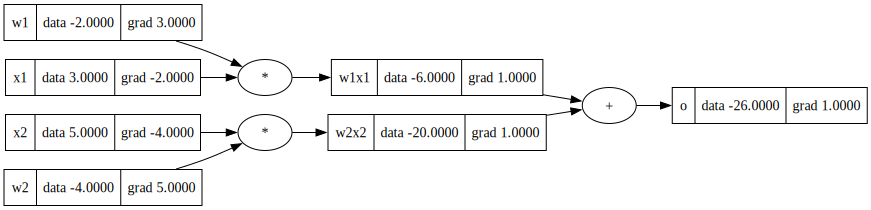

In [82]:
o.backward()
draw_dot(o)